# Exam 4th of January 2024, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!

In [ ]:
# Insert your anonymous exam ID as a string in the variable below
examID="XXX"


---
## Exam vB, PROBLEM 1
Maximum Points = 14


In this problem you will do rejection sampling from complicated distributions, you will also be using your samples to compute certain integrals, a method known as Monte Carlo integration: (Keep in mind that choosing a good sampling distribution is often key to avoid too much rejection)

1. [4p] Fill in the remaining part of the function `problem1_inversion` in order to produce samples from the below distribution using rejection sampling:

$$
    F[x] = 
    \begin{cases}
        0, & x \leq 0 \\
        \frac{e^{x^2}-1}{e-1}, & 0 < x < 1 \\
        1, & x \geq 1
    \end{cases}
$$

2. [2p] Produce 100000 samples (**use fewer if it times-out and you cannot find a solution**) and put the answer in `problem1_samples` from the above distribution and plot the histogram together with the true density. *(There is a timeout decorator on this function and if it takes more than 10 seconds to generate 100000 samples it will timeout and it will count as if you failed to generate.)*
3. [2p] Use the above 100000 samples (`problem1_samples`) to approximately compute the integral

$$
    \int_0^{1} \sin(x) \frac{2e^{x^2} x}{e-1} dx
$$
and store the result in `problem1_integral`.

4. [2p] Use Hoeffdings inequality to produce a 95\% confidence interval of the integral above and store the result as a tuple in the variable `problem1_interval`

5. [4p] Fill in the remaining part of the function `problem1_inversion_2` in order to produce samples from the below distribution using rejection sampling:
$$
    F[x] = 
    \begin{cases}
        0, & x \leq 0 \\
        20xe^{20-1/x}, & 0 < x < \frac{1}{20} \\
        1, & x \geq \frac{1}{20}
    \end{cases}
$$
Hint: this is tricky because if you choose the wrong sampling distribution you reject at least 9 times out of 10. You will get points based on how long your code takes to create a certain number of samples, if you choose the correct sampling distribution you can easily create 100000 samples within 2 seconds.

In [22]:

# Part 1

from Utils import timeout
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (2*x*np.exp(x**2))/(np.e-1)

def g(x):
    return 1 

M = (2*np.e)/(np.e-1)
def problem1_inversion(n_samples=1):
    samples = []
    while len(samples) < n_samples:
        x = np.random.uniform(0,1)
        r_x = f(x)/(M*g(x))
        U = np.random.uniform(0,1)
        if U <= r_x:
            samples.append(x)
    return np.array(samples)

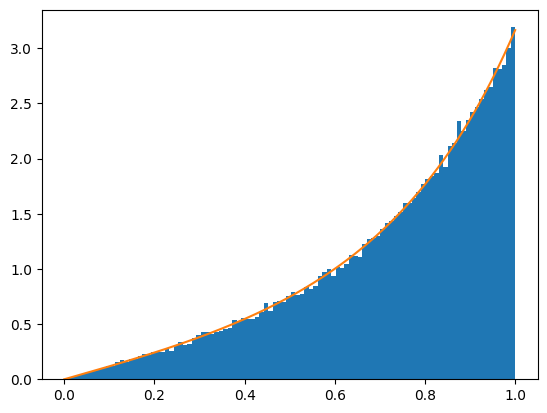

In [36]:
# Part 2

problem1_samples = problem1_inversion(n_samples=100000)



xs = np.linspace(0,1, num = 1000)

y = f(x = xs)
plt.hist(problem1_samples, density=True, bins = 100)
plt.plot(xs,y)

In [ ]:
# Part 3
problem1_integral = np.mean(np.sin(problem1_samples))
problem1_integral


np.float64(0.653186073045084)

In [98]:
# Part 4
n = 100000
epsilon = np.sqrt((np.log(2/0.05))/(2*n))
problem1_interval = [problem1_integral - epsilon,problem1_integral + epsilon]

In [50]:
# Part 5

def f(x):
    return 20*np.exp(20 - (1/x)) * (1 + (1/x))
M = 420

def g(x):
    return 20
def problem1_inversion_2(n_samples=1):
    samples = []
    while len(samples) < n_samples:
        x = np.random.uniform(0,1/20)
        r_x = f(x)/(M*g(x))
        U = np.random.uniform(0,1)
        if U <= r_x:
            samples.append(x)
    return np.array(samples)

---
#### Local Test for Exam vB, PROBLEM 1
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.

In [51]:

# This cell is just to check that you got the correct formats of your answer
import numpy as np
try:
    assert(isinstance(problem1_inversion(10), np.ndarray)) 
except:
    print("Try again. You should return a numpy array from problem1_inversion")
else:
    print("Good, your problem1_inversion returns a numpy array")

try:
    assert(isinstance(problem1_samples, np.ndarray)) 
except:
    print("Try again. your problem1_samples is not a numpy array")
else:
    print("Good, your problem1_samples is a numpy array")

try:
    assert(isinstance(problem1_integral, float)) 
except:
    print("Try again. your problem1_integral is not a float")
else:
    print("Good, your problem1_integral is a float")

try:
    assert(isinstance(problem1_interval, list) or isinstance(problem1_interval, tuple)) , "problem1_interval not a tuple or list"
    assert(len(problem1_interval) == 2) , "problem1_interval does not have length 2, it should have a lower bound and an upper bound"
except Exception as e:
    print(e)
else:
    print("Good, your problem1_interval is a tuple or list of length 2")

try:
    assert(isinstance(problem1_inversion_2(10), np.ndarray)) 
except:
    print("Try again. You should return a numpy array from problem1_inversion_2")
else:
    print("Good, your problem1_inversion_2 returns a numpy array")

Good, your problem1_inversion returns a numpy array
Good, your problem1_samples is a numpy array
Good, your problem1_integral is a float
Good, your problem1_interval is a tuple or list of length 2
Good, your problem1_inversion_2 returns a numpy array


---
## Exam vB, PROBLEM 2
Maximum Points = 13


Let us build a proportional model ($\mathbb{P}(Y=1 \mid X) = G(\beta_0+\beta \cdot X)$ where $G$ is the logistic function) for the spam vs not spam data. Here we assume that the features are presence vs not presence of a word, let $X_1,X_2,X_3$ denote the presence (1) or absence (0) of the words $("free", "prize", "win")$.

1. [2p] Load the file `data/spam.csv` and create two numpy arrays, `problem2_X` which has shape (n_emails,3) where each feature in `problem2_X` corresponds to $X_1,X_2,X_3$ from above, `problem2_Y` which has shape **(n_emails,)** and consists of a $1$ if the email is spam and $0$ if it is not. Split this data into a train-calibration-test sets where we have the split $40\%$, $20\%$, $40\%$, put this data in the designated variables in the code cell.

2. [4p] Follow the calculation from the lecture notes where we derive the logistic regression and implement the final loss function inside the class `ProportionalSpam`. You can use the `Test` cell to check that it gives the correct value for a test-point.

3. [4p] Train the model `problem2_ps` on the training data. The goal is to calibrate the probabilities output from the model. Start by creating a new variable `problem2_X_pred` (shape `(n_samples,1)`) which consists of the predictions of `problem2_ps` on the calibration dataset. Then train a calibration model using `sklearn.tree.DecisionTreeRegressor`, store this trained model in `problem2_calibrator`.

4. [3p] Use the trained model `problem2_ps` and the calibrator `problem2_calibrator` to make final predictions on the testing data, store the prediction in `problem2_final_predictions`. Compute the $0-1$ test-loss and store it in `problem2_01_loss` and provide a $99\%$ confidence interval of it, store this in the variable `problem2_interval`, this should again be a tuple as in **problem1**.

In [74]:
# Part 1
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('spam.csv', encoding='latin1')
df = df[['v1', 'v2']]

df['v2'] = df['v2'].str.lower()
X1 = df['v2'].apply(lambda x: 1 if 'free' in x else 0).to_numpy()
X2 = df['v2'].apply(lambda x: 1 if 'prize' in x else 0).to_numpy()
X3 = df['v2'].apply(lambda x: 1 if 'win' in x else 0).to_numpy()


problem2_X = np.column_stack((X1,X2,X3))
problem2_Y = (df['v1'] == 'spam').astype(int).to_numpy()

X_train,X_temp,Y_train,Y_temp = train_test_split(problem2_X,problem2_Y, shuffle=True, test_size=0.6)
X_calib,X_test,Y_calib,Y_test = train_test_split(X_temp,Y_temp,test_size=0.66, shuffle=True)
problem2_X_train = X_train
problem2_X_calib = X_calib
problem2_X_test = X_test

problem2_Y_train = Y_train
problem2_Y_calib = Y_calib
problem2_Y_test = Y_test

print(problem2_X_train.shape,problem2_X_calib.shape,problem2_X_test.shape,problem2_Y_train.shape,problem2_Y_calib.shape,problem2_Y_test.shape)

(2228, 3) (1136, 3) (2208, 3) (2228,) (1136,) (2208,)


In [95]:
# Part 2
from sklearn.tree import DecisionTreeRegressor
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

class ProportionalSpam(object):
    def __init__(self):
        self.coeffs = None
        self.result = None
    
    # define the objective/cost/loss function we want to minimise
    def loss(self, X, Y, coeffs):
        z = coeffs[0] + np.dot(coeffs[1:], X.T)
        pX = 1/(1+np.exp(-z))
        return -np.sum(Y*np.log(pX) + (1-Y)*np.log((1-pX)))/len(Y)
    

    def fit(self,X,Y):
        import numpy as np
        from scipy import optimize
        #Use the f above together with an optimization method from scipy
        #to find the coefficients of the model
        opt_loss = lambda coeffs: self.loss(X,Y,coeffs)
        initial_arguments = np.zeros(shape=X.shape[1]+1)
        self.result = optimize.minimize(opt_loss, initial_arguments,method='cg')
        self.coeffs = self.result.x
    
    def predict(self,X):
        #Use the trained model to predict Y
        if (self.coeffs is not None):
            G = lambda x: np.exp(x)/(1+np.exp(x))
            return np.round(10*G(np.dot(X,self.coeffs[1:])+self.coeffs[0]))/10 # This rounding is to help you with the calibration


In [102]:
# Part 3

problem2_ps = ProportionalSpam()
problem2_ps.fit(problem2_X_train,problem2_Y_train)

problem2_X_pred = problem2_ps.predict(problem2_X_calib).reshape(-1,1)

problem2_calibrator = DecisionTreeRegressor()
problem2_calibrator.fit(problem2_X_pred,problem2_Y_calib)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [105]:
# Part 4
raw_results = problem2_ps.predict(problem2_X_test).reshape(-1,1)

# These are the predicted probabilities
problem2_final_predictions = problem2_calibrator.predict(raw_results)
# In order to compute this loss we first need to convert the predicted probabilities to a decision
# recall the Bayes classifier?
problem2_preds = (problem2_final_predictions >= 0.5).astype(int)
problem2_01_loss = np.mean((problem2_preds == problem2_Y_test).astype(int))

n = len(problem2_Y_test)
epsilon = np.sqrt((np.log(2/0.01))/(2*n))
# Recall the interval is given as a tuple (a,b) or a list [a,b]
problem2_interval = (problem2_01_loss - epsilon, problem2_01_loss + epsilon)

---
#### Local Test for Exam vB, PROBLEM 2
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.

In [93]:
try:
    import numpy as np
    test_instance = ProportionalSpam()
    test_loss = test_instance.loss(np.array([[1,0,1],[0,1,1]]),np.array([1,0]),np.array([1.2,0.4,0.3,0.9]))
    assert (np.abs(test_loss-1.2828629432232497) < 1e-6)
    print("Your loss was correct for a test point")
except:
    print("Your loss was not correct on a test point")

Your loss was correct for a test point


---
## Exam vB, PROBLEM 3
Maximum Points = 13


Consider the following four Markov chains, answer each question for all chains:

<img width="400px" src="pictures/MarkovA.png">Markov chain A</img>
<img width="400px" src="pictures/MarkovB.png">Markov chain B</img>
<img width="400px" src="pictures/MarkovC.png">Markov chain C</img>
<img width="400px" src="pictures/MarkovD.png">Markov chain D</img>

1. [2p] What is the transition matrix?
2. [2p] Is the Markov chain irreducible?
3. [3p] Is the Markov chain aperiodic? What is the period for each state?
4. [3p] Does the Markov chain have a stationary distribution, and if so, what is it?
5. [3p] Is the Markov chain reversible?

In [3]:
# PART 1

#------------------------TRANSITION MATRIX -------------------------------
# Answer each one by supplying the transition matrix as a numpy array
# of shape (n_states,n_states), where state (A,B,...) corresponds to index (0,1,...)
import numpy as np

problem3_A    = np.array([
    [0.8, 0.2, 0.0, 0.0],  
    [0.6, 0.2, 0.2, 0.0],  
    [0.0, 0.4, 0.0, 0.6],  
    [0.0, 0.0, 0.8, 0.2],  
])
problem3_B    = np.array([
    [0.0, 0.2, 0.0, 0.8],  
    [0.0, 0.0, 1.0, 0.0],  
    [0.0, 1.0, 0.0, 0.0],  
    [0.5, 0.0, 0.5, 0.0],  
])
problem3_C    = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],  # A
    [0.2, 0.2, 0.6, 0.0, 0.0],  # B
    [0.0, 0.4, 0.0, 0.6, 0.0],  # C
    [0.0, 0.0, 0.0, 0.6, 0.4],  # D
    [0.0, 0.0, 0.0, 0.4, 0.6],  # E
])
problem3_D    = np.array([
    [0.8, 0.2, 0.0, 0.0],  # A
    [0.6, 0.2, 0.2, 0.0],  # B
    [0.0, 0.4, 0.0, 0.6],  # C
    [0.1, 0.0, 0.7, 0.2],  # D
])

In [5]:
import numpy as np
import networkx as nx


#this code works by converting the markov chain into graph and checking if it's strongly connected
def is_reducible(P):
    G = nx.DiGraph()
    n = P.shape[0]

    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j)

    return not nx.is_strongly_connected(G)

In [7]:
# PART 2
#------------------------REDUCIBLE -------------------------------
# Answer each one with a True or False

problem3_A_irreducible = not is_reducible(problem3_A)
problem3_B_irreducible = not is_reducible(problem3_B)
problem3_C_irreducible = not is_reducible(problem3_C)
problem3_D_irreducible = not is_reducible(problem3_D)


print(problem3_A_irreducible,problem3_B_irreducible,problem3_C_irreducible,problem3_D_irreducible)


True False False True


In [10]:
import numpy as np
from math import gcd
from functools import reduce

def state_period(P, i, max_power=50, tol=1e-12):
    n = P.shape[0]
    Pn = np.eye(n)
    return_times = []

    for k in range(1, max_power + 1):
        Pn = Pn @ P
        if Pn[i, i] > tol:
            return_times.append(k)

    if not return_times:
        return None  # should not happen in finite irreducible chains

    return reduce(gcd, return_times)

def is_aperiodic(P):
    n = P.shape[0]
    periods = [state_period(P, i) for i in range(n)]
    return all(p == 1 for p in periods)


def periods_of_chain(P):
    return [state_period(P, i) for i in range(P.shape[0])]


In [ ]:
# PART 3
#------------------------APERIODIC-------------------------------
# Answer each one with a True or False

problem3_A_is_aperiodic = is_aperiodic(problem3_A)
problem3_B_is_aperiodic = is_aperiodic(problem3_B)
problem3_C_is_aperiodic = is_aperiodic(problem3_C)
problem3_D_is_aperiodic = is_aperiodic(problem3_D)

# Answer the following with the period of the states as a numpy array
# of shape (n_states,)

problem3_A_periods = periods_of_chain(problem3_A)
problem3_B_periods = periods_of_chain(problem3_B)
problem3_C_periods = periods_of_chain(problem3_C)
problem3_D_periods = periods_of_chain(problem3_D)



[1, 1, 1, 1]

In [16]:
def stationary_distribution(P):
    n = P.shape[0]

    A = np.vstack([
        P.T - np.eye(n),
        np.ones(n)
    ])
    b = np.zeros(n + 1)
    b[-1] = 1

    # Least-squares solve (robust to rank deficiency)
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    return pi

In [17]:
# PART 4
#------------------------STATIONARY DISTRIBUTION-----------------
# Answer each one with a True or False

problem3_A_has_stationary = True
problem3_B_has_stationary = True
problem3_C_has_stationary = True
problem3_D_has_stationary = True

# Answer the following with the stationary distribution as a numpy array of shape (n_states,)
# if the Markov chain has a stationary distribution otherwise answer with False

problem3_A_stationary_dist = stationary_distribution(problem3_A)
problem3_B_stationary_dist = stationary_distribution(problem3_B)
problem3_C_stationary_dist = stationary_distribution(problem3_C)
problem3_D_stationary_dist = stationary_distribution(problem3_D)



In [18]:
def is_reversible(P, tol=1e-10):
    pi = stationary_distribution(P)
    n = P.shape[0]

    for i in range(n):
        for j in range(n):
            if abs(pi[i] * P[i, j] - pi[j] * P[j, i]) > tol:
                return False
    return True

In [19]:
# PART 5
#------------------------REVERSIBLE-----------------
# Answer each one with a True or False

problem3_A_is_reversible = is_reversible(problem3_A)
problem3_B_is_reversible = is_reversible(problem3_B)
problem3_C_is_reversible = is_reversible(problem3_C)
problem3_D_is_reversible = is_reversible(problem3_D)